C:\Users\o\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 33021 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\Users\o\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 28304 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\Users\o\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 23494 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\Users\o\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 38598 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\Users\o\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 22411 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\Users\o\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 20135 missing from current font.
  font.set_

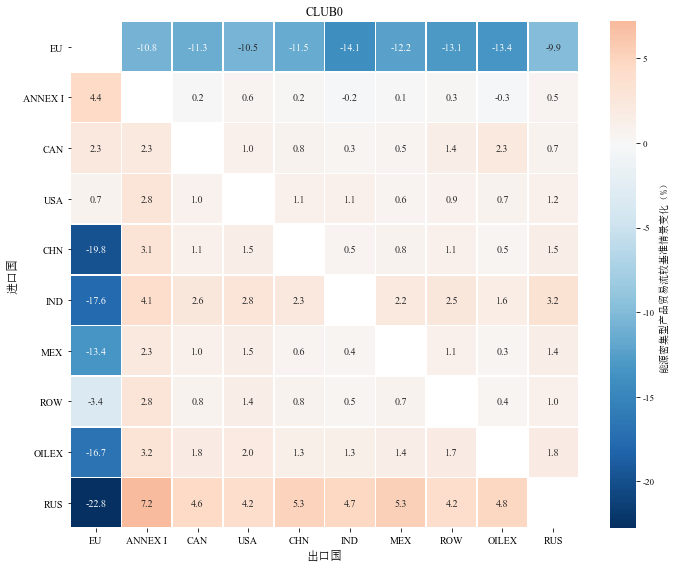

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib import rcParams
from matplotlib.font_manager import FontProperties

# 设置全局字体为 Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.unicode_minus'] = False

# 中文宋体用于 colorbar label
simsun_font = FontProperties(fname='C:/Windows/Fonts/simsun.ttc', size=10)

# 读取数据
file_path = 'club1.xls'
sheet_name = 'CBA_flow_com'

df = pd.read_excel(file_path, sheet_name=sheet_name, index_col=0)

# 替换特殊值为 NaN 并将所有数据转为 float
df.replace('Undf', np.nan, inplace=True)
df = df.astype(float)


# 统一国家顺序
order = ['EU', 'ANNEX I', 'CAN', 'USA', 'CHN', 'IND', 'MEX', 'ROW', 'OILEX', 'RUS']
df = df.loc[order, order]

# 绘制热力图
plt.figure(figsize=(10, 8))
ax = sns.heatmap(df, annot=True, fmt=".1f", cmap='RdBu_r', center=0,
                 linewidths=0.5, cbar_kws={"label": "能源密集型产品贸易流较基准情景变化（%）"})

# 设置轴标签字体
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

# 设置 colorbar 字体为宋体
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.label.set_font_properties(simsun_font)
cbar.ax.tick_params(labelsize=9)

# 设置中文标签
plt.title('CLUB0', fontsize=12)
plt.xlabel('出口国', fontsize=12,fontname='Simsun')
plt.ylabel('进口国', fontsize=12,fontname='Simsun',)

plt.tight_layout()

# 显示图像
plt.show()


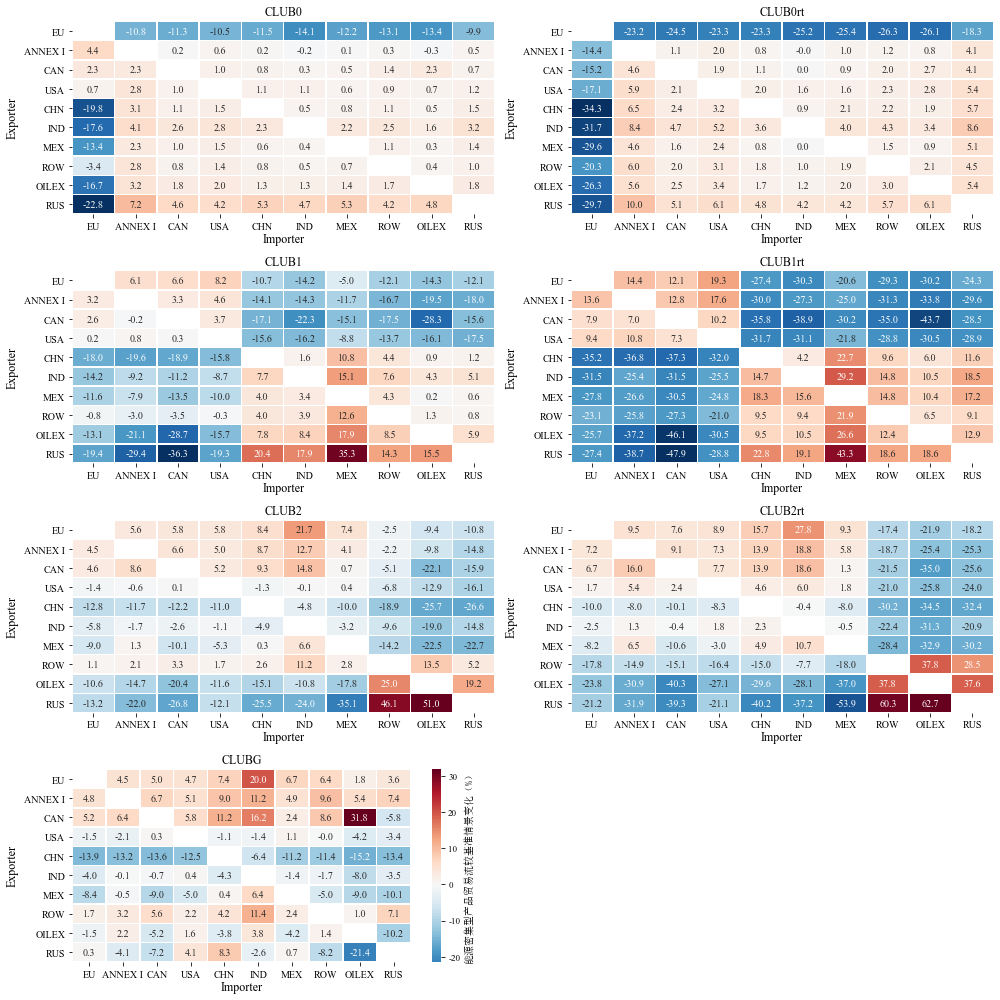

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.font_manager import FontProperties

# 设置字体
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.unicode_minus'] = False
simsun_font = FontProperties(fname='C:/Windows/Fonts/simsun.ttc', size=10)

# 📁 文件名和标题列表
files_titles = [
    ('club1.xls', 'CLUB0'),
    ('club1rt.xls', 'CLUB0rt'),
    ('club4.xls', 'CLUB1'),
    ('club4rt.xls', 'CLUB1rt'),
    ('club7.xls', 'CLUB2'),
    ('club7rt.xls', 'CLUB2rt'),
    ('club10.xls', 'CLUBG')
]

# ✅ 国家顺序
order = ['EU', 'ANNEX I', 'CAN', 'USA', 'CHN', 'IND', 'MEX', 'ROW', 'OILEX', 'RUS']

# ✅ 创建画布：4行×2列子图（最后一张 CLUBG 放在左下角）
fig, axes = plt.subplots(4, 2, figsize=(14, 22))
axes = axes.flatten()

# ✅ 通用绘图函数
def draw_heatmap(ax, df, title, show_cbar=False):
    # 数据清洗
    df.replace('Undf', np.nan, inplace=True)
    df = df.astype(float)
    df = df.loc[order, order]

    # 绘图
    sns.heatmap(
        df, annot=True, fmt=".1f", cmap='RdBu_r', center=0,
        linewidths=0.5, ax=ax,
        cbar=show_cbar,
        cbar_kws={"label": "能源密集型产品贸易流较基准情景变化（%）"} if show_cbar else None
    )

    # 坐标轴设置
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=10)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
    ax.set_xlabel('Importer', fontsize=12, labelpad=2)
    ax.set_ylabel('Exporter', fontsize=12, labelpad=5)
    ax.set_title(title, fontsize=12)
    
    # 色带设置
    if show_cbar:
        cbar = ax.collections[0].colorbar
        cbar.ax.yaxis.label.set_font_properties(simsun_font)
        cbar.ax.tick_params(labelsize=9)

# ✅ 前6张图（无色阶）
for i in range(6):
    fname, title = files_titles[i]
    df = pd.read_excel(fname, sheet_name='CBA_flow_com', index_col=0)
    draw_heatmap(axes[i], df, title, show_cbar=False)

# ✅ 第7张图 CLUBG（有色阶），放在第7格（行3列1）
df_last = pd.read_excel('club10.xls', sheet_name='CBA_flow_com', index_col=0)
draw_heatmap(axes[6], df_last, 'CLUBG', show_cbar=True)

# ✅ 删除最后一个空图位（行3列2）
fig.delaxes(axes[7])

# ✅ 导出图像
plt.tight_layout()
plt.savefig('tradeflow_7clubs.png', dpi=600, bbox_inches='tight')
plt.show()


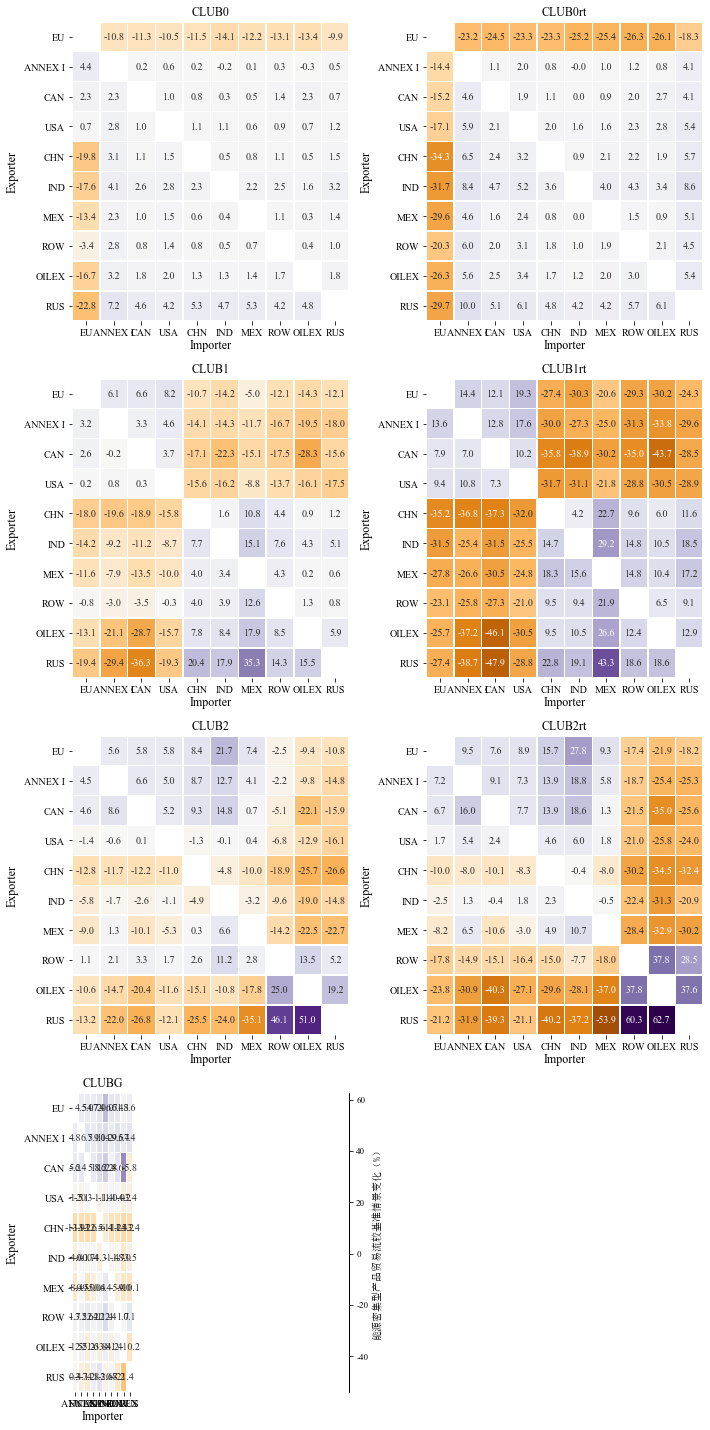

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.font_manager import FontProperties
from mpl_toolkits.axes_grid1 import make_axes_locatable

# 设置字体
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.unicode_minus'] = False
simsun_font = FontProperties(fname='C:/Windows/Fonts/simsun.ttc', size=10)

# 文件名和标题列表
files_titles = [
    ('club1.xls', 'CLUB0'),
    ('club1rt.xls', 'CLUB0rt'),
    ('club4.xls', 'CLUB1'),
    ('club4rt.xls', 'CLUB1rt'),
    ('club7.xls', 'CLUB2'),
    ('club7rt.xls', 'CLUB2rt'),
    ('club10.xls', 'CLUBG')
]

# 国家顺序
order = ['EU', 'ANNEX I', 'CAN', 'USA', 'CHN', 'IND', 'MEX', 'ROW', 'OILEX', 'RUS']

# ✅ 统一色阶：预读取数据计算全局 vmin/vmax
vmin, vmax = float('inf'), float('-inf')
data_frames = []

for fname, _ in files_titles:
    df_tmp = pd.read_excel(fname, sheet_name='CBA_flow_com', index_col=0)
    df_tmp.replace('Undf', np.nan, inplace=True)
    df_tmp = df_tmp.astype(float)
    df_tmp = df_tmp.loc[order, order]
    data_frames.append(df_tmp)
    vmin = min(vmin, df_tmp.min().min())
    vmax = max(vmax, df_tmp.max().max())

# ✅ 创建画布：4行×2列子图（最后一张 CLUBG 放在左下角）
fig, axes = plt.subplots(4, 2, figsize=(10, 20))
axes = axes.flatten()

# ✅ 通用绘图函数
def draw_heatmap(ax, df, title, show_cbar=False):
    sns.heatmap(
        df, annot=True, fmt=".1f", cmap='PuOr', center=0,
        linewidths=0.5, ax=ax,
        cbar=show_cbar,
        vmin=vmin, vmax=vmax,
        cbar_kws={"label": "能源密集型产品贸易流较基准情景变化（%）"} if show_cbar else None
    )
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=10)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
    ax.set_xlabel('Importer', fontsize=12, labelpad=2)
    ax.set_ylabel('Exporter', fontsize=12, labelpad=5)
    ax.set_title(title, fontsize=12)
    if show_cbar:
        cbar = ax.collections[0].colorbar
        cbar.ax.yaxis.label.set_font_properties(simsun_font)
        cbar.ax.tick_params(labelsize=9)

# ✅ 前6张图（无色阶）
for i in range(6):
    draw_heatmap(axes[i], data_frames[i], files_titles[i][1], show_cbar=False)

# ✅ 第7张图（有色阶），保持大小一致 + 独立色阶
draw_heatmap(axes[6], data_frames[6], 'CLUBG', show_cbar=False)
from mpl_toolkits.axes_grid1 import make_axes_locatable

divider = make_axes_locatable(axes[6])
cax = divider.append_axes("right", size="1%", pad=3)

cb = fig.colorbar(axes[6].collections[0], cax=cax)
cb.set_label("能源密集型产品贸易流较基准情景变化（%）", fontproperties=simsun_font, fontsize=10)
cb.ax.tick_params(labelsize=9)

# 删除第8个空子图
fig.delaxes(axes[7])

# 导出图像
plt.tight_layout(pad=1.2)
plt.savefig('tradeflow_7clubs.png', dpi=600, bbox_inches='tight')
plt.show()


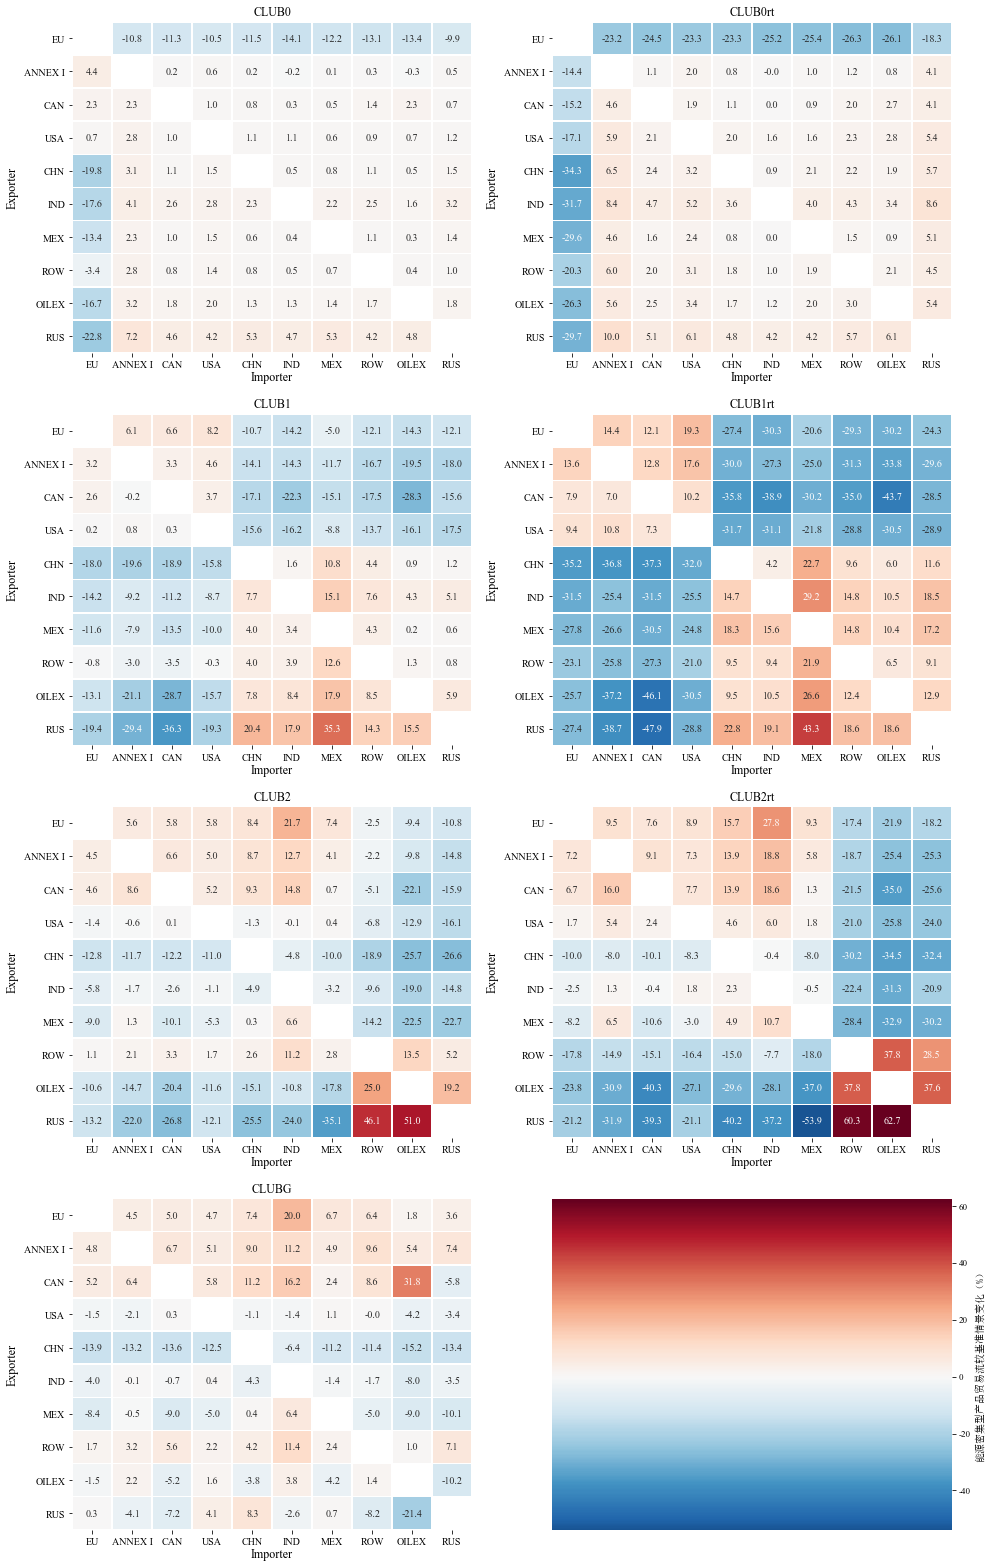

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.font_manager import FontProperties
from mpl_toolkits.axes_grid1 import make_axes_locatable

# 设置字体
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.unicode_minus'] = False
simsun_font = FontProperties(fname='C:/Windows/Fonts/simsun.ttc', size=10)

# 文件名和标题列表
files_titles = [
    ('club1.xls', 'CLUB0'),
    ('club1rt.xls', 'CLUB0rt'),
    ('club4.xls', 'CLUB1'),
    ('club4rt.xls', 'CLUB1rt'),
    ('club7.xls', 'CLUB2'),
    ('club7rt.xls', 'CLUB2rt'),
    ('club10.xls', 'CLUBG')
]

# 国家顺序
order = ['EU', 'ANNEX I', 'CAN', 'USA', 'CHN', 'IND', 'MEX', 'ROW', 'OILEX', 'RUS']

# 统一色阶：预读取全部数据，计算全局 vmin/vmax
vmin, vmax = float('inf'), float('-inf')
data_frames = []

for fname, _ in files_titles:
    df_tmp = pd.read_excel(fname, sheet_name='CBA_flow_com', index_col=0)
    df_tmp.replace('Undf', np.nan, inplace=True)
    df_tmp = df_tmp.astype(float)
    df_tmp = df_tmp.loc[order, order]
    data_frames.append(df_tmp)
    vmin = min(vmin, df_tmp.min().min())
    vmax = max(vmax, df_tmp.max().max())

# 创建画布：4行×2列子图（不删除最后一个图，让它用于放色阶）

# 修改 subplot 创建部分
# 创建子图，注意对齐
fig, axes = plt.subplots(4, 2, figsize=(14, 22))
axes = axes.flatten()


# 通用绘图函数
def draw_heatmap(ax, df, title, show_cbar=False, cbar_ax=None):
    sns.heatmap(
        df, annot=True, fmt=".1f", cmap='PuOr', center=0,
        linewidths=0.5, ax=ax,
        cbar=show_cbar,
        cbar_ax=cbar_ax,
        vmin=vmin, vmax=vmax,
        cbar_kws={"label": "能源密集型产品贸易流较基准情景变化（%）"} if show_cbar else None
    )
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=10)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
    ax.set_xlabel('Importer', fontsize=12, labelpad=2)
    ax.set_ylabel('Exporter', fontsize=12, labelpad=5)
    ax.set_title(title, fontsize=12)
    if show_cbar:
        cbar = ax.collections[0].colorbar
        cbar.ax.yaxis.label.set_font_properties(simsun_font)
        cbar.ax.tick_params(labelsize=9)

# 前6张图（无色阶）
for i in range(6):
    draw_heatmap(axes[i], data_frames[i], files_titles[i][1], show_cbar=False)

# CLUBG 图放在第7格，色阶在第8格
draw_heatmap(axes[6], data_frames[6], 'CLUBG', show_cbar=True, cbar_ax=axes[7])
from mpl_toolkits.axes_grid1 import make_axes_locatable

divider = make_axes_locatable(axes[6])
cax = divider.append_axes("right", size="3%", pad=0.1)

# 调整 colorbar 标签字体
axes[7].set_ylabel("能源密集型产品贸易流较基准情景变化（%）", fontproperties=simsun_font, fontsize=10)
axes[7].tick_params(labelsize=9)

# 导出图像
plt.tight_layout(pad=1.5)
plt.savefig('tradeflow_7clubs.png', dpi=600, bbox_inches='tight')
plt.show()


IndexError: list index out of range

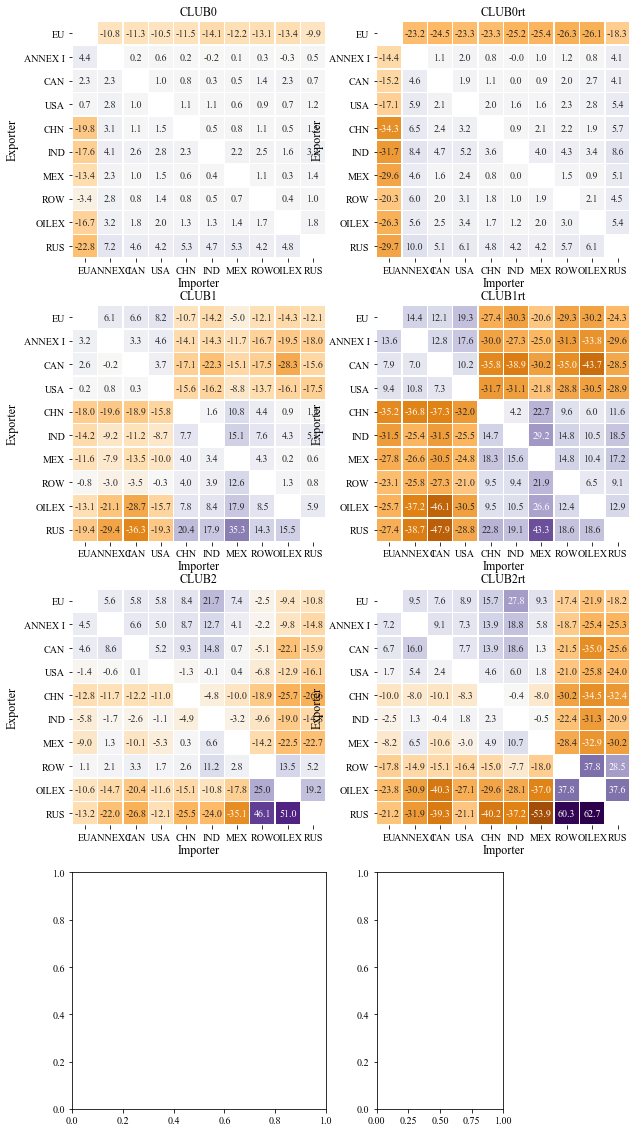

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.font_manager import FontProperties
from mpl_toolkits.axes_grid1 import make_axes_locatable

# 设置字体
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.unicode_minus'] = False
simsun_font = FontProperties(fname='C:/Windows/Fonts/simsun.ttc', size=10)

# 文件名和标题列表
files_titles = [
    ('club1.xls', 'CLUB0'),
    ('club1rt.xls', 'CLUB0rt'),
    ('club4.xls', 'CLUB1'),
    ('club4rt.xls', 'CLUB1rt'),
    ('club7.xls', 'CLUB2'),
    ('club7rt.xls', 'CLUB2rt'),
    ('club10.xls', 'CLUBG')
]

# 国家顺序
order = ['EU', 'ANNEX I', 'CAN', 'USA', 'CHN', 'IND', 'MEX', 'ROW', 'OILEX', 'RUS']

# ✅ 统一色阶：预读取数据计算全局 vmin/vmax
vmin, vmax = float('inf'), float('-inf')
data_frames = []

for fname, _ in files_titles:
    df_tmp = pd.read_excel(fname, sheet_name='CBA_flow_com', index_col=0)
    df_tmp.replace('Undf', np.nan, inplace=True)
    df_tmp = df_tmp.astype(float)
    df_tmp = df_tmp.loc[order, order]
    data_frames.append(df_tmp)
    vmin = min(vmin, df_tmp.min().min())
    vmax = max(vmax, df_tmp.max().max())

# ✅ 创建画布：4行×2列子图（最后一张 CLUBG 放在左下角）
fig, axes = plt.subplots(4, 2, figsize=(10, 20))
axes = axes.flatten()

# ✅ 通用绘图函数
def draw_heatmap(ax, df, title, show_cbar=False):
    sns.heatmap(
        df, annot=True, fmt=".1f", cmap='PuOr', center=0,
        linewidths=0.5, ax=ax,
        cbar=show_cbar,
        vmin=vmin, vmax=vmax,
        cbar_kws={"label": "能源密集型产品贸易流较基准情景变化（%）"} if show_cbar else None
    )
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=10)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
    ax.set_xlabel('Importer', fontsize=12, labelpad=2)
    ax.set_ylabel('Exporter', fontsize=12, labelpad=5)
    ax.set_title(title, fontsize=12)
    if show_cbar:
        cbar = ax.collections[0].colorbar
        cbar.ax.yaxis.label.set_font_properties(simsun_font)
        cbar.ax.tick_params(labelsize=9)

# ✅ 前6张图（无色阶）
for i in range(6):
    draw_heatmap(axes[i], data_frames[i], files_titles[i][1], show_cbar=False)

from mpl_toolkits.axes_grid1 import make_axes_locatable

# 清空 axes[7] 内容（避免出现多余图）
axes[7].axis('off')

# 在 axes[7] 上划分位置
divider = make_axes_locatable(axes[7])
cax = divider.append_axes("left", size="100%", pad=0.0)  # ← 使用整个 axes[7] 区域

# 添加 colorbar，使用第7张图的热力图对象
cb = fig.colorbar(axes[6].collections[0], cax=cax, orientation='vertical')
cb.set_label("能源密集型产品贸易流较基准情景变化（%）", fontproperties=simsun_font, fontsize=10)
cb.ax.tick_params(labelsize=9)

# 调整 ticks 标签字体
cb.ax.yaxis.set_tick_params(labelsize=9)


# 导出图像
plt.tight_layout(pad=1.2)
plt.savefig('tradeflow_7clubs.png', dpi=600, bbox_inches='tight')
plt.show()


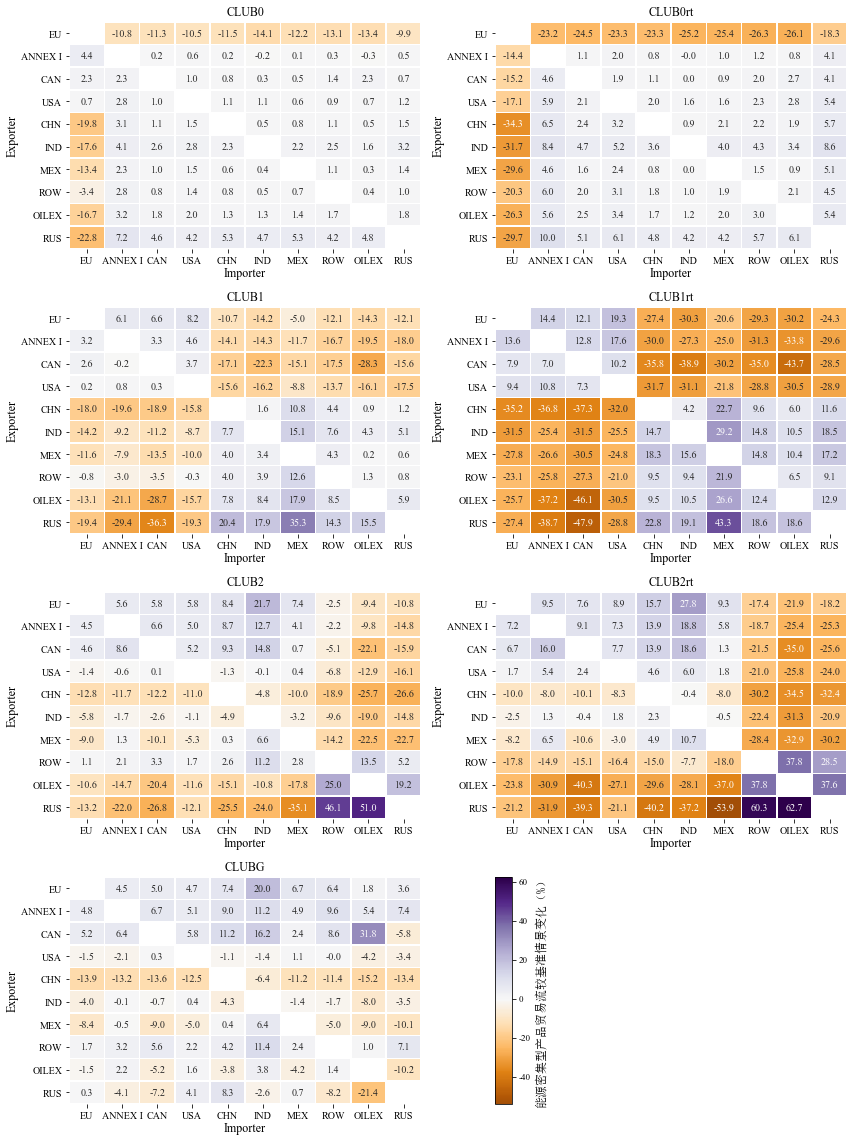

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.font_manager import FontProperties
from mpl_toolkits.axes_grid1 import make_axes_locatable

# 设置字体
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.unicode_minus'] = False
simsun_font = FontProperties(fname='C:/Windows/Fonts/simsun.ttc', size=10)

# 文件名和标题列表
files_titles = [
    ('club1.xls', 'CLUB0'),
    ('club1rt.xls', 'CLUB0rt'),
    ('club4.xls', 'CLUB1'),
    ('club4rt.xls', 'CLUB1rt'),
    ('club7.xls', 'CLUB2'),
    ('club7rt.xls', 'CLUB2rt'),
    ('club10.xls', 'CLUBG')
]

# 国家顺序
order = ['EU', 'ANNEX I', 'CAN', 'USA', 'CHN', 'IND', 'MEX', 'ROW', 'OILEX', 'RUS']

# ✅ 统一色阶：预读取数据计算全局 vmin/vmax
vmin, vmax = float('inf'), float('-inf')
data_frames = []

for fname, _ in files_titles:
    df_tmp = pd.read_excel(fname, sheet_name='CBA_flow_com', index_col=0)
    df_tmp.replace('Undf', np.nan, inplace=True)
    df_tmp = df_tmp.astype(float)
    df_tmp = df_tmp.loc[order, order]
    data_frames.append(df_tmp)
    vmin = min(vmin, df_tmp.min().min())
    vmax = max(vmax, df_tmp.max().max())

# ✅ 创建画布：4行×2列子图（最后一张 CLUBG 放在左下角）
fig, axes = plt.subplots(4, 2, figsize=(12, 16))
axes = axes.flatten()

# ✅ 通用绘图函数
def draw_heatmap(ax, df, title, show_cbar=False):
    sns.heatmap(
        df, annot=True, fmt=".1f", cmap='PuOr', center=0,
        linewidths=0.5, ax=ax,
        cbar=show_cbar,
        vmin=vmin, vmax=vmax,
        cbar_kws={"label": "能源密集型产品贸易流较基准情景变化（%）"} if show_cbar else None
    )
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=10)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
    ax.set_xlabel('Importer', fontsize=12, labelpad=2)
    ax.set_ylabel('Exporter', fontsize=12, labelpad=2)
    ax.set_title(title, fontsize=12)
    if show_cbar:
        cbar = ax.collections[0].colorbar
        cbar.ax.yaxis.label.set_font_properties(simsun_font)
        cbar.ax.tick_params(labelsize=8)

# ✅ 前6张图（无色阶）
for i in range(6):
    draw_heatmap(axes[i], data_frames[i], files_titles[i][1], show_cbar=False)

# ✅ 第7张图 CLUBG（画图但不显示色阶）
draw_heatmap(axes[6], data_frames[6], 'CLUBG', show_cbar=False)

# ✅ 第8格用于色阶
axes[7].axis('off')
divider = make_axes_locatable(axes[7])
cax = divider.append_axes("left", size="5%", pad=0.0)

# ✅ 添加 colorbar 使用 CLUBG 的映射对象
cb = fig.colorbar(axes[6].collections[0], cax=cax, orientation='vertical')
cb.set_label("能源密集型产品贸易流较基准情景变化（%）", fontproperties=simsun_font, fontsize=12)
cb.ax.tick_params(labelsize=9)

# ✅ 导出图像
plt.tight_layout(pad=1.2)
plt.savefig('tradeflow_7clubs.svg', format='svg', bbox_inches='tight')
